# Character Identification CNN Model
Ze Hao version

### Import Modules

This notebook uses PyTorch for the processing.

In [180]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import cv2
import os

from torchvision.transforms import v2

In [212]:
train_data_dir = "./chars_train_data"

### Object Classes
Set up the mapping of each character label to the label ID

In [181]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

36



### Setting up the dataset and dataloaders (incl. img transforms)

For more information about creating custom dataset and using dataloader, check out [this tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).


In [216]:
# CV2 PREPROCESSING BELOW
def cv2_preprocess(img):
    # --- Convert to grayscale ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # --- Invert so character = white (255), background = black (0) ---
    gray = 255 - gray
    
    # --- Threshold to make binary ---
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # --- Find bounding box of character ---
    coords = cv2.findNonZero(binary)
    x, y, w, h = cv2.boundingRect(coords)
    
    # --- Crop + 3px padding ---
    pad = 3
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, binary.shape[1])
    y2 = min(y + h + pad, binary.shape[0])
    cropped = binary[y1:y2, x1:x2]
    
    # Below: Pad or crop all letters to the same 36*36 square (while avoiding stretching proportions)
    # --- Create 36*36 black background ---
    target_size = 36
    canvas = np.zeros((target_size, target_size), dtype=np.uint8)
    
    # --- If cropped image is larger than 32x32, center crop it ---
    h, w = cropped.shape
    if h > target_size or w > target_size:
        # Center crop
        start_y = max((h - target_size) // 2, 0)
        start_x = max((w - target_size) // 2, 0)
        end_y = start_y + target_size
        end_x = start_x + target_size
        cropped = cropped[start_y:end_y, start_x:end_x]
        h, w = cropped.shape
    
    # --- Compute top-left position to center the image ---
    y_offset = (target_size - h) // 2
    x_offset = (target_size - w) // 2
    
    # --- Paste cropped image onto canvas ---
    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = cropped
            
    # --- Convert to float tensor in [0, 1] ---
    canvas = canvas.astype(np.float32) / 255.0
    canvas = torch.tensor(canvas).unsqueeze(0)  # shape (1, H, W)

    return canvas

In [217]:
class CharDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir="", transform=None, is_train=True):
        self.data_dir = data_dir
        
        # Get all PNG files
        self.image_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.png') or f.lower().endswith('.PNG')]
        if len(self.image_files) == 0:
            raise FileNotFoundError(f"No .png files found in {data_dir}")

        # Extract labels from filenames (everything before the first '_')
        self.labels = [f.split('_')[0] for f in self.image_files]
        
        self.is_train = is_train
        
    def __len__(self):
        return len(self.image_files) # Number of samples in dataset
        
    def __getitem__(self, index): # Defines what happens when a new sample is gotten from dataset
        fname = self.image_files[index]
        label_str = self.labels[index]
        label_idx = char_classes[label_str]

        img_path = os.path.join(self.data_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Cannot read image {img_path}")

        # Preprocess img with cv2
        img = cv2_preprocess(img)

        return fname, img, label_idx


In [ ]:
train_dataset = CharDataset(data_dir=train_data_dir, transform=transform, is_train=True)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=50, shuffle=True)

test_dataset = CharDataset(data_dir=train_data_dir, transform=transform, is_train=False)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=50, shuffle=False)

### Inspect and visualize your data

It is recommended to inspect some samples of your data through visualization

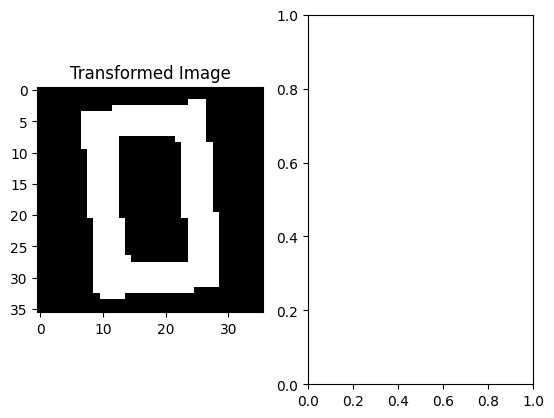

0
0_00000.png


In [198]:
img_id, X_transformed, y = train_dataset[0]

fig, ax = plt.subplots(nrows=1, ncols=2)
ax[0].imshow(F.to_pil_image(X_transformed), cmap='gray')
ax[0].title.set_text('Transformed Image')
plt.show()
print(y)
print(img_id)


### Setting up the GPU

Kaggle provides GPU to speed up neural network evaluations. To activate it, click on Accelerator and select GPU. Note that there is a usage quota, so use it wisely.


In [199]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu



# Setting up your neural network model

As mentioned in the Getting Started section, you should check out this tutorial. Although not covered in lectures, you should consider learning and using these:

- Convolutional neural network layers ([``torch.nn.Conv2D``](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html))
- Maxpool layers ([``torch.nn.MaxPool2d``](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html))
- Adam optimizer ([``torch.nn.Adam``](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
- [Pre-trained models](https://pytorch.org/vision/stable/models.html)
- [Loss functions](https://pytorch.org/docs/stable/nn.html#loss-functions)



In [275]:
import torch.nn as nn
import torch.nn.functional as F

# Add your Neural Network here (if using NN)

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 16, 3)
        
        self.fc1 = nn.Linear(16 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Conv layer -> Relu -> Maxpool
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = Model()
net.to(device)

def count_params(net, trainable=False):
    if trainable:
        count = sum(p.numel() for p in net.parameters() if p.requires_grad)
    else:
        count = sum(p.numel() for p in net.parameters())
    return count

print(F'Network has {count_params(net, trainable=False)} parameters in total')
print(F'Network has {count_params(net, trainable=True)} trainable parameters in total')

Network has 55060 parameters in total
Network has 55060 trainable parameters in total


# Training the Model

In [276]:
from tqdm import tqdm # for a progress bar

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
num_epochs = 30

epoch_losses = []  # store loss for each epoch

for epoch in range(num_epochs):
    net.train()  # set model to training mode
    running_loss = 0.0 
    # Running loss sums the loss values for each mini-batch, to later compute the average loss per epoch

    for img_id, X_transformed, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        X_transformed, y = X_transformed.to(device), y.to(device)

        # Forward pass
        y_pred_logits = net(X_transformed)
        loss = criterion(y_pred_logits, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")
    epoch_losses.append(avg_loss)


Epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████| 886/886 [00:25<00:00, 34.17it/s]


Epoch [1/5] - Loss: 1.8920


Epoch 2/5: 100%|█████████████████████████████████████████████████████████████████████| 886/886 [00:26<00:00, 32.90it/s]


Epoch [2/5] - Loss: 1.1293


Epoch 3/5: 100%|█████████████████████████████████████████████████████████████████████| 886/886 [00:26<00:00, 33.53it/s]


Epoch [3/5] - Loss: 0.9751


Epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████| 886/886 [00:25<00:00, 34.98it/s]


Epoch [4/5] - Loss: 0.8882


Epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████| 886/886 [00:25<00:00, 34.46it/s]

Epoch [5/5] - Loss: 0.8249


### Plot Training Loss

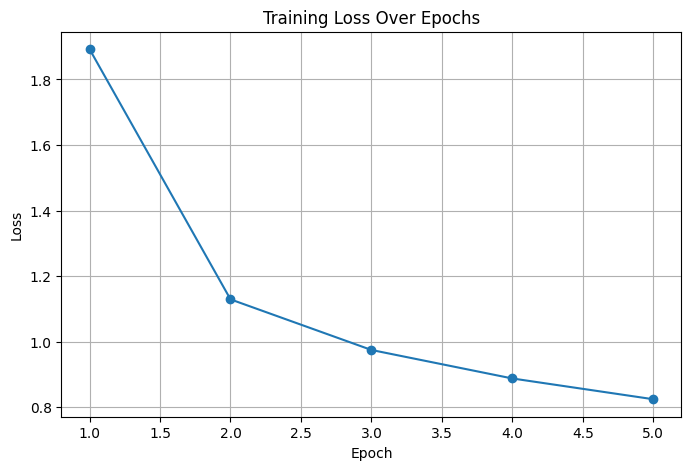

In [278]:
# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Making predictions
Naive: Simply take the highest logit and take it as prediction.

In [228]:
def predict(y_pred_logits): 
    # Take the index of the highest logit for each sample
    y_pred = torch.argmax(y_pred_logits, dim=1) # Note: returns a tensor
    return y_pred

### Evaluate on Train set

In [282]:
net.eval()  # set model to evaluation mode (disables dropout/batchnorm)
correct = 0
total = 0


with torch.no_grad():
    for img_id, X_transformed, y in tqdm(train_dataloader):
        X_transformed = X_transformed.to(device)
        y = y.to(device)

        # Forward pass
        outputs = net(X_transformed)
        
        # Predicted class = index of max logit
        predicted = predict(outputs)

        # Count correct predictions
        total += y.size(0)
        correct += (predicted == y).sum().item()

train_accuracy = 100 * correct / total
print(f'Total: {total}')
print(f'Correct: {correct}')
print(f'Accuracy on Train Data: {train_accuracy:.2f}%')


100%|████████████████████████████████████████████████████████████████████████████████| 886/886 [00:18<00:00, 47.13it/s]

Total: 44299
Correct: 33807
Accuracy on Train Data: 76.32%


### Inference on single sample

In [279]:
def predict_single_image(net, img_path, char_classes, show=True):
    # Load img
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")

    # Preprocess
    x = cv2_preprocess(img)  
    x = x.unsqueeze(0).to(device)  # add batch dimension -> (1, 1, 36, 36)

    net.eval()
    with torch.no_grad():
        output = net(x)
        predicted_class = predict(output).item()

    # Map index back to character
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[predicted_class]
    
    if show:
        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        # Original image
        ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax[0].set_title(f"File: {img_path}")
        ax[0].axis("off")
        # Processed (grayscale)
        ax[1].imshow(x.squeeze().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Processed (Pred: {predicted_label})")
        ax[1].axis("off")
        plt.tight_layout()
        plt.show()
        
    return predicted_label

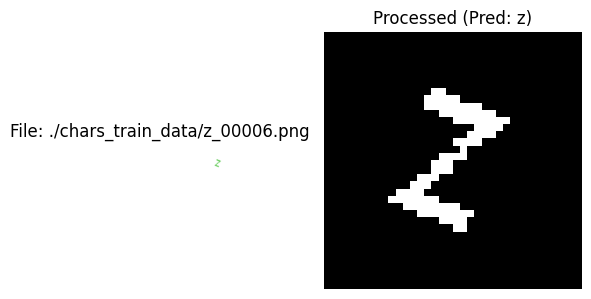

In [281]:
img_path = "./chars_train_data/z_00006.png"
pred = predict_single_image(net, img_path, char_classes, show=True)